In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import random

## File Reading

In [2]:
def unpack_data(paired_list):
    labels = [label for label, _ in paired_list]
    data = [features for _, features in paired_list]
    return labels, data

In [3]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

1


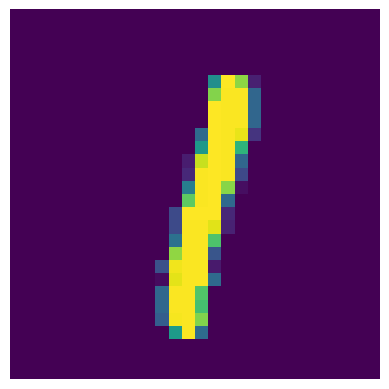

In [10]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [18]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    # only use digits 1–8, and only take 400 of each
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


## The Perceptron(s)

In [20]:
# One for each number
w0 = np.random.uniform(0, 0.5, size=785)  
w1 = np.random.uniform(0, 0.5, size=785)  
w2 = np.random.uniform(0, 0.5, size=785)  
w3 = np.random.uniform(0, 0.5, size=785)  
w4 = np.random.uniform(0, 0.5, size=785)  
w5 = np.random.uniform(0, 0.5, size=785)  
w6 = np.random.uniform(0, 0.5, size=785)  
w7 = np.random.uniform(0, 0.5, size=785)  
w8 = np.random.uniform(0, 0.5, size=785)  
w9 = np.random.uniform(0, 0.5, size=785)  

def perceptron_run(number_array, w):
    x0 = 1
    input_array = np.insert(number_array, 0, x0) 
    
    summation = np.dot(w, input_array) 

    # Activation function (step)
    output = 1 if summation > 0 else 0

    return output

In [22]:
# Prepping the data for the perceptron

training_data_copy = []

# Perceptron 1
training_data_copy = [
    (1 if label == 0 else 0, features.copy()) 
    for label, features in combined_train_data
]

In [28]:
training_data_copy[2002]

(0,
 array([0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.    